The Lea-Coulson dynamics are too complicated. Here we will proceed with an adjustment to the continuous model that we described earlier, in which we will consider the periods in which at least one mutant is likely to be present in the culture.

Consider a population of 1000 bacteria at the start of the experiment. If the mutation rate is low, e.g. of the order of 10<sup>-8</sup>, it would be unlikely that one of those cells would be mutant. In a continuous model however, the mutant population starts immediately and is allowed to grow. This fallacy can be addressed by **estimating the time at which the first mutant appears**.

So, we can create a new model in which mutants do not exist at the beginning of this experiment, i.e. *m(τ)=0* for τ < τ<sub>0</sub>.

$$
S(τ)=Ντ_0e^{(1-μ)(τ-τ_0)}
$$

$$
m(τ)=Ντ_0e^{(τ-τ_0)}μ(τ-τ_0)
$$

At the end of the experiment, when *τ=τ<sub>f</sub>* and the final number of cells is *N<sub>f</sub>=N<sub>τ<sub>0</sub></sub>e<sup>(τ<sub>f</sub>-τ<sub>0</sub>)</sup>*, we can write:

$$
m(τ_f)=Ν_fμ(τ_f-τ_0).
$$

Recall that due to the exponential bacterial growth, *τ<sub>f</sub>-τ<sub>0</sub>=log(N<sub>f</sub>/N<sub>τ<sub>0</sub></sub>).*

In the actual lab, the measurable experimental observations are:

*   the number of mutants *m*,
*   the total number of bacteria *N<sub>f</sub>*, and
*   the duration of growth *τ<sub>f</sub>*.

If we know the approximate time at which resistant mutants appear, we would be able to estimate μ (the mutation rate). This time is related to *N<sub>τ<sub>0</sub></sub>*. This completes the puzzle.





If one resistant bacteria was generated by one million bacteria, you would expect to wait until the number of bacteria in the culture are in the order of millions before observing the first mutant. In mathematical terms, this would mean that the time of appearence of the first mutant should satisfy *N<sub>τ<sub>0</sub></sub> μ = 1*, or *N<sub>τ<sub>0</sub></sub> = 1/μ*.

Taking all of the above into consideration, we can substitute the time in the above equation and get:

$$
m(τ)=N_fμ\:log(N_fμ)
$$

If there are C replicates, then the first time that a mutant appears in any one of the replicates would be of the order of 1/C<sub>μ</sub> such that:

$$
m(τ)=N_fμ\:log(CN_fμ)
$$

We can put this equation into practice. Given a number of mutants *m*, the number of replicates *C*, and population size *N<sub>f</sub>*, we can identify a unique value of *μ*.

# What about the variance?

As mentioned before, mutations are less likely to happen early, but when they do, they result in higher numbers of mutants. It is more likely that they will appear later in the experiment, and when they do, they give rise to smaller number of mutants. These different instances of mutation appearance will contribute to variation across multiple repetitions of the experiment.
If you only had mutants at two time points, e.g., *τ<sub>0</sub>* and *τ<sub>1</sub>*, the total variance would be:

$$
Var(m)=Var(m|τ_0)+Var(m|τ_1)
$$

The number of new mutants in any given generation is a random Poisson number, *m=N(τ)μ*. However, as the culture is allowed to grow, the number of mutants grow exponentially.

Remember that in Poisson distributions the variance is approximately equal to the mean. Given the exponential growth however, the variance of the mutants will be multiplied by an exponential factor. As an example, if the culture is allowed to grow by a factor of 8, the variance will grow by a factor of *8<sup>2</sup>=64*.

With the above focus on two distinct times of mutation appearance (for simplicity), we can estimate variation:

$$
Var(m)=(e^{τ_f-τ_0})^2μN(τ_0)+(e^{τ_f-τ_1})^2μN(τ_1)
$$

In exponential growth, N(τ<sub>1</sub>)=N<sub>f</sub>e<sup>-(τ<sub>f</sub>-τ<sub>0</sub>)</sup>, and so:

$$
Var(m)=μN_f[e^{τ_f-τ_0}+e^{τ_f-τ_1}]
$$

This idea can be used to include any values of time between τ<sub>0</sub> and τ<sub>1</sub> by integration. Skipping the calculus steps, this will result in:

$$
Var(m)=μN_f(CμN_f-1)≈C(μN_f)^2
$$

This shows that the **variance then will grow faster than the mean**.

Write a program to simulate one generation of the Luria Delbruck experiment. Simulate C = 500 cultures, each of which has N=1000 cells and mu=10<sup>-3</sup>, i.e. very high mutation rate. What is the distribution of resistant mutants that you observe across all the cultures? Are they similar or dissimilar to each other? Specify c(m), i.e. the number of cultures with m resistant mutants. Is this distribution well fit by a Poisson distribution, If so, what is the best fit shape parameter of the Poisson density function and how does it relate to the value of the mutation?

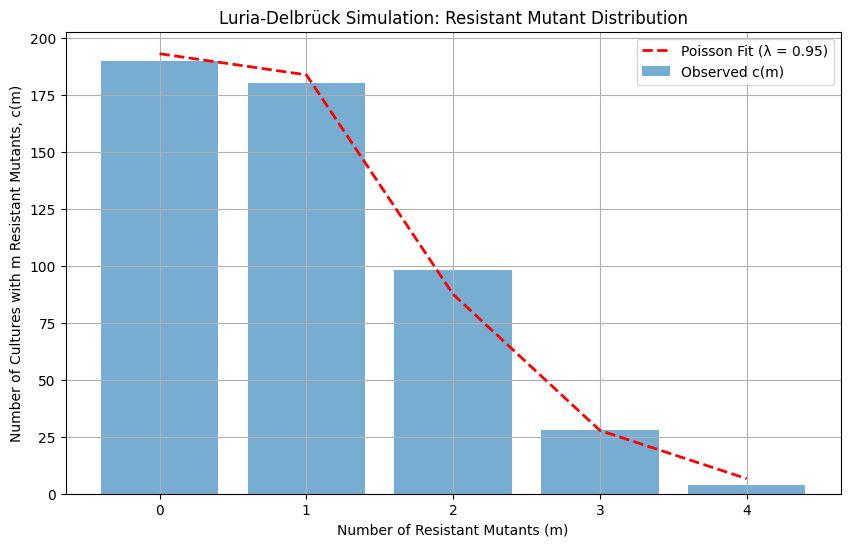

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from collections import Counter

# Parameters
C = 500          # number of cultures
N = 1000         # number of cells per culture
mu = 1e-3        # mutation probability per cell

# Simulate resistant mutants for each culture
resistant_counts = np.random.binomial(n=N, p=mu, size=C)

# Count c(m): number of cultures with m resistant mutants
count_dict = Counter(resistant_counts)
max_m = max(count_dict.keys())
cm = [count_dict.get(m, 0) for m in range(max_m + 1)]

# Estimate Poisson parameter (mean of observed distribution)
lambda_hat = np.mean(resistant_counts)
poisson_pmf = [poisson.pmf(m, mu=lambda_hat) * C for m in range(max_m + 1)]

# Plot results
plt.figure(figsize=(10,6))
plt.bar(range(max_m + 1), cm, alpha=0.6, label="Observed c(m)")
plt.plot(range(max_m + 1), poisson_pmf, 'r--', linewidth=2, label=f"Poisson Fit (λ = {lambda_hat:.2f})")
plt.xlabel("Number of Resistant Mutants (m)")
plt.ylabel("Number of Cultures with m Resistant Mutants, c(m)")
plt.title("Luria-Delbrück Simulation: Resistant Mutant Distribution")
plt.legend()
plt.grid(True)
plt.show()

Answer the following questions:

1.   Are the cultures similar?
2.   What is the shape of the distribution?
3.   From the plot, what is the best-fit λ?









Now extend the program from the last question. Set C=1000, N=400, and μ=10<sup>-7</sup>. Have the population grow over g=15 generations. What choice did you make with respect to modeling the population? If you decided to model each individual cell in each individual culture, explain your rationale. Next, develop a model that represents the emergence of new resistance cells in each generation in each culture en masse, that is, all at once. Hint, think about how prudent use of the Poisson random generation function could help. The objective here is to develop a working simulation that is both accurate and efficient. In doing so, compare the speed when you use Poisson versus binomial random number generating functions.

In [2]:
# Model A: Binomial-based distribution.
# Sensitive cells divide in each generation to produce new cells, with each generation having μ probability of mutation

import numpy as np
import time

# Parameters
C = 1000
g = 15
mu = 1e-7

def simulate_binomial():
    mutants = np.zeros(C, dtype=int)
    sensitive = np.ones(C, dtype=int)  # start with 1 cell

    for gen in range(g):
        # Each cell divides → population doubles
        divisions = sensitive

        # New mutations (binomial draw)
        new_mut = np.random.binomial(divisions, mu)

        # Update counts
        sensitive = 2 * sensitive - new_mut
        mutants = 2 * mutants + new_mut

    return mutants

# Timing
start = time.time()
mut_binom = simulate_binomial()
end = time.time()

print("Binomial runtime:", end - start)

Binomial runtime: 0.004233598709106445


In [3]:
# Model B: Poisson-based simulation
# Remember that when μ is very small and Ν is very large, the binomial and Poisson distributions are very similar.

def simulate_poisson():
    mutants = np.zeros(C, dtype=int)
    sensitive = np.ones(C, dtype=int)

    for gen in range(g):
        divisions = sensitive

        # Poisson approximation
        new_mut = np.random.poisson(divisions * mu)

        sensitive = 2 * sensitive - new_mut
        mutants = 2 * mutants + new_mut

    return mutants

# Timing
start = time.time()
mut_pois = simulate_poisson()
end = time.time()

print("Poisson runtime:", end - start)

Poisson runtime: 0.0030159950256347656


In [4]:
# Compare the speed

import time

# Binomial timing
start = time.time()
simulate_binomial()
t_binom = time.time() - start

# Poisson timing
start = time.time()
simulate_poisson()
t_pois = time.time() - start

print("Binomial:", t_binom)
print("Poisson:", t_pois)

Binomial: 0.003992319107055664
Poisson: 0.0013928413391113281


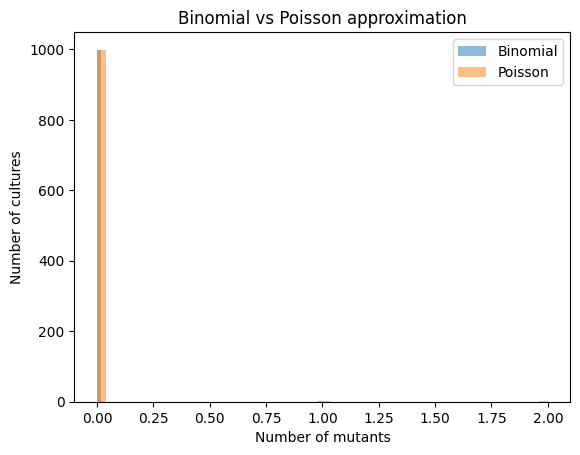

In [5]:
# Compare the outputs

import matplotlib.pyplot as plt

plt.hist(mut_binom, bins=50, alpha=0.5, label="Binomial")
plt.hist(mut_pois, bins=50, alpha=0.5, label="Poisson")
plt.legend()
plt.xlabel("Number of mutants")
plt.ylabel("Number of cultures")
plt.title("Binomial vs Poisson approximation")
plt.show()

Why does this model still produce jackpot events?